# Loan Default Risk — Exploratory Data Analysis

---

### Background

SuperLender is a Nigerian digital lending company that uses credit risk models to decide who gets a loan, how much, and at what price. Their approach is built around two fundamental questions: is this person willing to pay, and are they able to pay? Both questions need to be answered at the point of application, before any money changes hands.

This notebook is purely exploratory. No models are built here. The goal is to understand the data deeply enough that every modelling decision in the next notebook has a clear justification rooted in what the data actually shows.

We work with three linked tables:

- `trainperf.csv` : the loan we are trying to predict, including the target variable `good_bad_flag`
- `traindemographics.csv` : customer demographic information collected at registration
- `trainprevloans.csv` : the complete history of every prior loan each customer has taken before this one

The target variable is binary. Good (1) means the customer repaid on time. Bad (0) means they did not.

---

## 1. Imports and Setups

Standard library imports and display configuration. The `sys.path.append` line allows us to import functions from `src/` so that loading and feature engineering logic stays in reusable scripts rather than being duplicated across notebooks.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Allow imports from src/
sys.path.append(os.path.abspath(".."))

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

## 2. Load Raw Data

In [56]:
from src.loader import load_raw_tables

perf, demo, prev = load_raw_tables(split="train")

print(f"trainperf:      {perf.shape}")
print(f"traindemographics: {demo.shape}")
print(f"trainprevloans: {prev.shape}")

trainperf:      (4368, 10)
traindemographics: (4346, 9)
trainprevloans: (18183, 12)


We use `load_raw_tables()` from `src/loader.py` to bring in all three tables at once.

The shapes are the first useful piece of information. The performance table has 4,368 rows, the demographics table has 4,346, and the previous loans table has 18,183. The performance and demographics tables are close but not identical, meaning a small number of customers appear in one but not the other. We will handle this wlater on so no prediction targets are dropped.

The previous loans table having 18,183 rows for roughly 4,300 customers means each customer has an average of about 4 prior loans on record. That is enough history to build meaningful behavioural features.

In [57]:
perf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.00,34500.00,30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.00,17250.00,30,NaN,Good
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.00,22250.00,15,NaN,Good
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.00,11500.00,15,NaN,Good
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.00,44000.00,30,NaN,Good


In [58]:
perf.info()

<class 'pandas.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customerid     4368 non-null   str    
 1   systemloanid   4368 non-null   int64  
 2   loannumber     4368 non-null   int64  
 3   approveddate   4368 non-null   str    
 4   creationdate   4368 non-null   str    
 5   loanamount     4368 non-null   float64
 6   totaldue       4368 non-null   float64
 7   termdays       4368 non-null   int64  
 8   referredby     587 non-null    str    
 9   good_bad_flag  4368 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 341.4 KB


In [59]:
# Missing values
perf.isnull().sum()

customerid          0
systemloanid        0
loannumber          0
approveddate        0
creationdate        0
loanamount          0
totaldue            0
termdays            0
referredby       3781
good_bad_flag       0
dtype: int64

good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64
good_bad_flag
Good   78.20
Bad    21.80
Name: proportion, dtype: float64


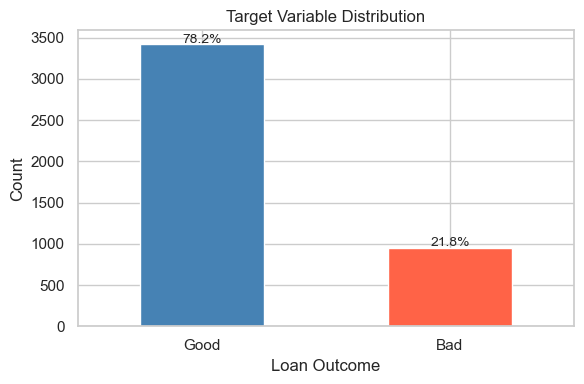

In [60]:
# Target variable distribution
target_counts = perf["good_bad_flag"].value_counts()
target_pct = perf["good_bad_flag"].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_title("Target Variable Distribution")
ax.set_xlabel("Loan Outcome")
ax.set_ylabel("Count")
ax.set_xticklabels(["Good", "Bad"], rotation=0)
for i, v in enumerate(target_counts):
    ax.text(i, v + 20, f"{target_pct.iloc[i]:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/figures/target_distribution.png", dpi=150)
plt.show()

From this plot we can see that target distribution is `78.2%` Good, `21.8%` Bad. About 1 in 5 loans defaults. The imbalance is real and will need handling but it is not so extreme that the minority class is invisible.

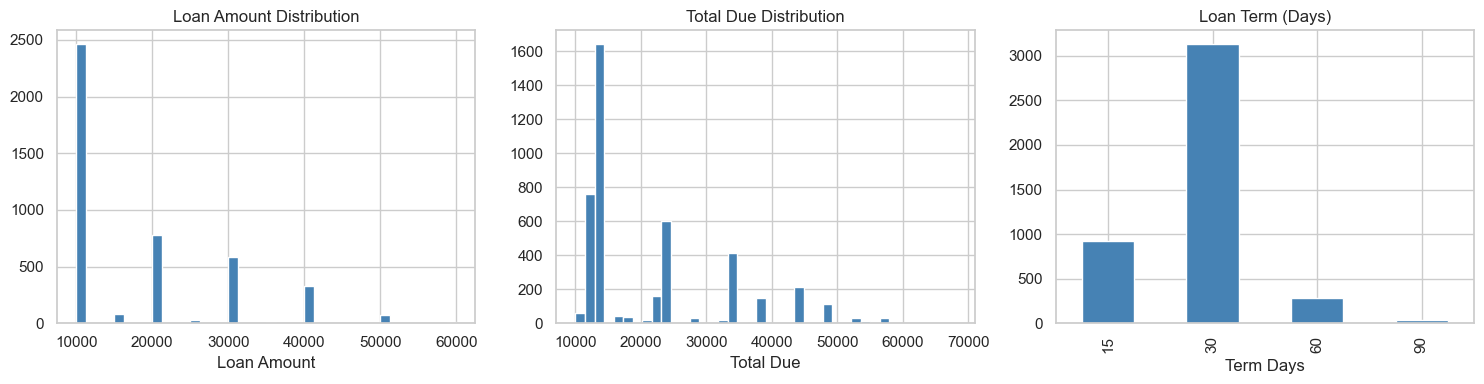

In [61]:
# Loan amount and term distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

perf["loanamount"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Loan Amount Distribution")
axes[0].set_xlabel("Loan Amount")

perf["totaldue"].hist(bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Total Due Distribution")
axes[1].set_xlabel("Total Due")

perf["termdays"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="steelblue", edgecolor="white")
axes[2].set_title("Loan Term (Days)")
axes[2].set_xlabel("Term Days")

plt.tight_layout()
plt.savefig("../outputs/figures/loan_distributions.png", dpi=150)
plt.show()

It seems most loans are 10,000 naira on 30-day terms. The product is standardised. Customers are not negotiating bespoke loan sizes, they are picking from a small menu. This limits how much the loan amount itself can tell us about risk.

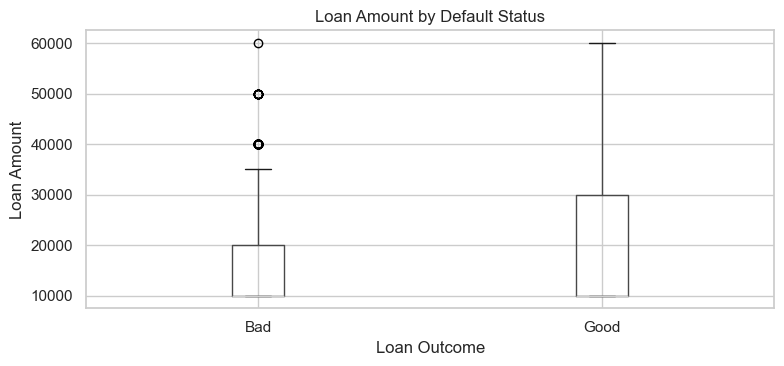

In [62]:
# Loan amount by target class
fig, ax = plt.subplots(figsize=(8, 4))
perf.boxplot(column="loanamount", by="good_bad_flag", ax=ax)
ax.set_title("Loan Amount by Default Status")
ax.set_xlabel("Loan Outcome")
ax.set_ylabel("Loan Amount")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 3. Demographic Data

In [63]:
demo.head()

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10 00:00:00.000000,Savings,3.32,6.53,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21 00:00:00.000000,Savings,3.33,7.12,Sterling Bank,NaN,Permanent,NaN
2,8a858e5b5bd99460015bdc95cd485634,1987-04-01 00:00:00.000000,Savings,5.75,5.56,Fidelity Bank,NaN,NaN,NaN
3,8a858efd5ca70688015cabd1f1e94b55,1991-07-19 00:00:00.000000,Savings,3.36,6.64,GT Bank,NaN,Permanent,NaN
4,8a858e785acd3412015acd48f4920d04,1982-11-22 00:00:00.000000,Savings,8.46,11.97,GT Bank,NaN,Permanent,NaN


In [64]:
demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   str    
 1   birthdate                   4346 non-null   str    
 2   bank_account_type           4346 non-null   str    
 3   longitude_gps               4346 non-null   float64
 4   latitude_gps                4346 non-null   float64
 5   bank_name_clients           4346 non-null   str    
 6   bank_branch_clients         51 non-null     str    
 7   employment_status_clients   3698 non-null   str    
 8   level_of_education_clients  587 non-null    str    
dtypes: float64(2), str(7)
memory usage: 305.7 KB


In [65]:
# Missing values as percentages
missing = (demo.isnull().sum() / len(demo) * 100).round(1)
print(missing[missing > 0])

bank_branch_clients          98.80
employment_status_clients    14.90
level_of_education_clients   86.50
dtype: float64


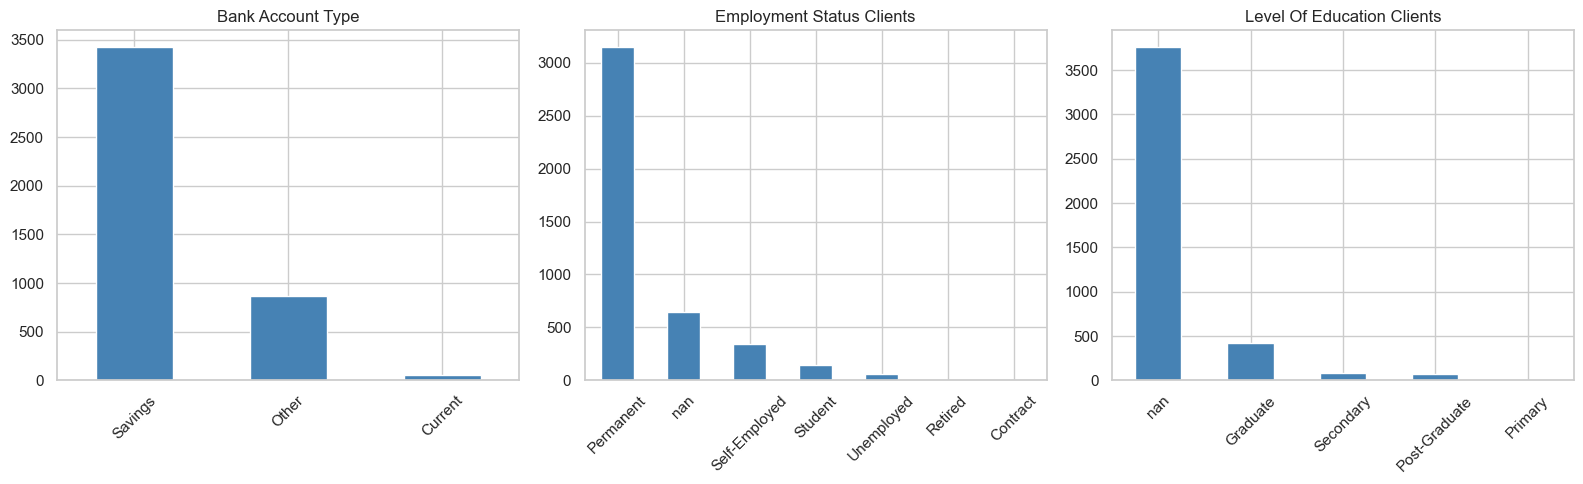

In [66]:
# Categorical feature distributions
cat_cols = ["bank_account_type", "employment_status_clients", "level_of_education_clients"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    counts = demo[col].value_counts(dropna=False)
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/demographic_distributions.png", dpi=150)
plt.show()

The plots shows that almost everyone has a Savings account. Most who disclosed employment are Permanently employed. Education is basically useless as a feature since 86.5% of customers never filled it in. The missing bars dominate two of the three charts.

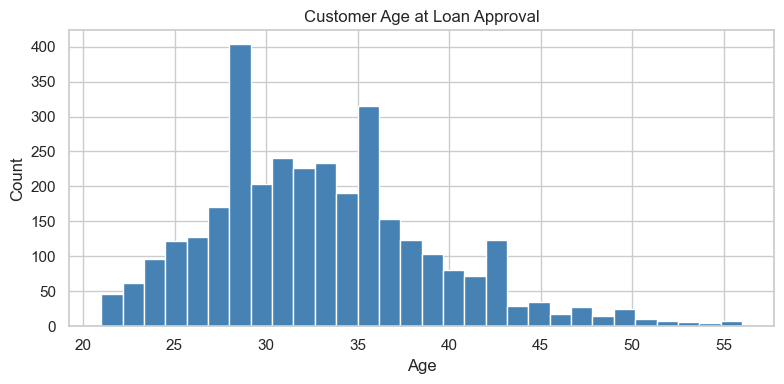

count   3277.00
mean      32.94
std        6.13
min       21.00
25%       28.00
50%       32.00
75%       37.00
max       56.00
Name: age, dtype: float64


In [67]:
# Age distribution — merge perf dates to compute age at application
demo_perf = perf[["customerid", "approveddate"]].merge(demo[["customerid", "birthdate"]], on="customerid")
demo_perf["approveddate"] = pd.to_datetime(demo_perf["approveddate"])
demo_perf["birthdate"] = pd.to_datetime(demo_perf["birthdate"])
demo_perf["age"] = ((demo_perf["approveddate"] - demo_perf["birthdate"]).dt.days / 365.25).round(0)

fig, ax = plt.subplots(figsize=(8, 4))
demo_perf["age"].hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Customer Age at Loan Approval")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/figures/age_distribution.png", dpi=150)
plt.show()

print(demo_perf["age"].describe())

Age distribution peaks at 28-29, median around 32, range 21 to 56. Young working-age Nigerians. The distribution is clean with no obvious data quality issues.

In [68]:
prev.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40.000000,2016-08-15 17:22:32.000000,10000.00,13000.00,30,2016-09-01 16:06:48.000000,NaN,2016-09-14 00:00:00.000000,2016-09-01 15:51:43.000000
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07.000000,2017-04-28 17:38:53.000000,10000.00,13000.00,30,2017-05-28 14:44:49.000000,NaN,2017-05-30 00:00:00.000000,2017-05-26 00:00:00.000000
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25.000000,2017-03-05 09:56:19.000000,20000.00,23800.00,30,2017-04-26 22:18:56.000000,NaN,2017-04-04 00:00:00.000000,2017-04-26 22:03:47.000000
3,8a8588f35438fe12015444567666018e,301861541,5,2017-04-09 18:25:55.000000,2017-04-09 17:25:42.000000,10000.00,11500.00,15,2017-04-24 01:35:52.000000,NaN,2017-04-24 00:00:00.000000,2017-04-24 00:48:43.000000
4,8a85890754145ace015429211b513e16,301941754,2,2017-06-17 09:29:57.000000,2017-06-17 08:29:50.000000,10000.00,11500.00,15,2017-07-14 21:18:43.000000,NaN,2017-07-03 00:00:00.000000,2017-07-14 21:08:35.000000


In [69]:
prev.info()

<class 'pandas.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       18183 non-null  str    
 1   systemloanid     18183 non-null  int64  
 2   loannumber       18183 non-null  int64  
 3   approveddate     18183 non-null  str    
 4   creationdate     18183 non-null  str    
 5   loanamount       18183 non-null  float64
 6   totaldue         18183 non-null  float64
 7   termdays         18183 non-null  int64  
 8   closeddate       18183 non-null  str    
 9   referredby       1026 non-null   str    
 10  firstduedate     18183 non-null  str    
 11  firstrepaiddate  18183 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 1.7 MB


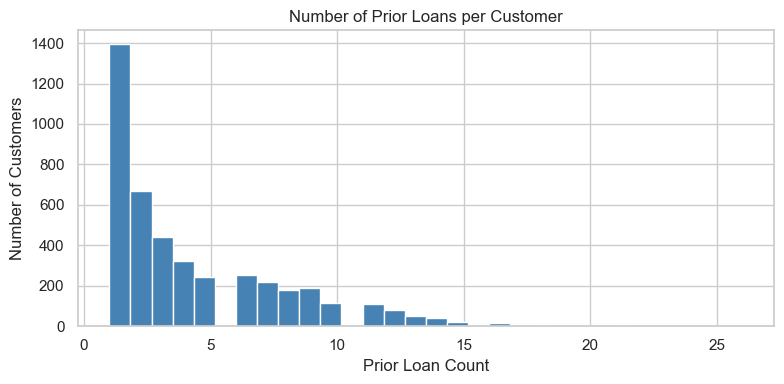

count   4359.00
mean       4.17
std        3.65
min        1.00
25%        1.00
50%        3.00
75%        6.00
max       26.00
Name: systemloanid, dtype: float64


In [70]:
# How many prior loans does each customer have?
loan_counts = prev.groupby("customerid")["systemloanid"].count()

fig, ax = plt.subplots(figsize=(8, 4))
loan_counts.hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Number of Prior Loans per Customer")
ax.set_xlabel("Prior Loan Count")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../outputs/figures/prior_loan_counts.png", dpi=150)
plt.show()

print(loan_counts.describe())

Most customers have between 1 and 5 prior loans. Nearly 1,400 customers have only 1. Those customers are the hardest to score because one data point is not a pattern.

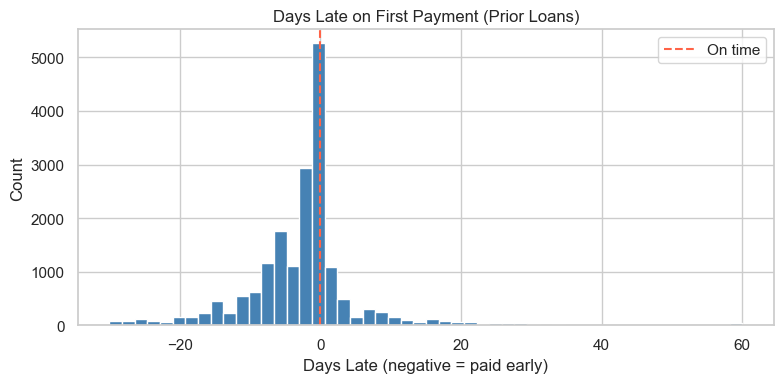

Percentage of prior loans paid late: 17.4%


In [71]:
# Compute days late on first payment for each previous loan
prev_dates = prev.copy()
prev_dates["firstduedate"] = pd.to_datetime(prev_dates["firstduedate"])
prev_dates["firstrepaiddate"] = pd.to_datetime(prev_dates["firstrepaiddate"])
prev_dates["days_late"] = (prev_dates["firstrepaiddate"] - prev_dates["firstduedate"]).dt.days

fig, ax = plt.subplots(figsize=(8, 4))
prev_dates["days_late"].clip(-30, 60).hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(0, color="tomato", linestyle="--", label="On time")
ax.set_title("Days Late on First Payment (Prior Loans)")
ax.set_xlabel("Days Late (negative = paid early)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/days_late_distribution.png", dpi=150)
plt.show()

late_pct = (prev_dates["days_late"] > 0).mean() * 100
print(f"Percentage of prior loans paid late: {late_pct:.1f}%")

The giant spike is exactly at zero, meaning most prior payments were made right on time or within a day. There is a decent left tail of early payers and a right tail of late payers stretching to 60 days. Late payments are not evenly spread, they tend to cluster in the 5 to 15 day range.

## 5. New vs Repeat Customers

In [72]:
# Check how many customers in trainperf have prior loan history
repeat_customers = set(prev["customerid"].unique())
all_customers = set(perf["customerid"].unique())
new_customers = all_customers - repeat_customers

print(f"Total customers in trainperf:       {len(all_customers)}")
print(f"Customers with prior loan history:  {len(repeat_customers & all_customers)}")
print(f"New customers (no prior history):   {len(new_customers)}")
print(f"\nThis dataset is {(1 - len(new_customers)/len(all_customers))*100:.1f}% repeat customers.")

Total customers in trainperf:       4368
Customers with prior loan history:  4359
New customers (no prior history):   9

This dataset is 99.8% repeat customers.


## 6. Behavioural Features vs Target

In [73]:
# Engineer prevloans features and merge with target to explore relationships
from src.features import engineer_prevloans_features

prev_features = engineer_prevloans_features(prev)
perf_with_target = perf[["customerid", "good_bad_flag"]].copy()
merged = perf_with_target.merge(prev_features, on="customerid", how="left")

merged.head()

,customerid,good_bad_flag,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_avg_days_late,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred
0,8a2a81a74ce8c05d014cfb32a0da1049,Good,11.00,18181.82,30000.00,22081.82,30.00,-0.91,39.00,0.27,3.00,0.23,29.45,0.00
1,8a85886e54beabf90154c0a29ae757c0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,Good,6.00,10000.00,10000.00,11750.00,17.50,0.83,30.00,0.17,1.00,0.18,18.17,0.00
3,8a85890754145ace015429211b513e16,Good,2.00,10000.00,10000.00,12250.00,22.50,7.50,11.00,1.00,2.00,0.22,31.50,0.00
4,8a858970548359cc0154883481981866,Good,8.00,18750.00,30000.00,23550.00,37.50,-3.12,-1.00,0.00,0.00,0.26,27.00,0.00


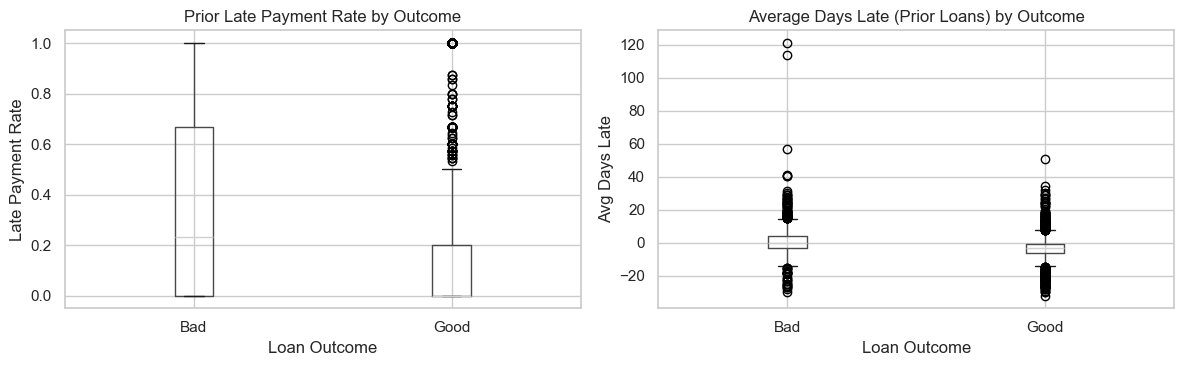

In [74]:
# Late payment rate by target class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

merged.boxplot(column="prev_late_payment_rate", by="good_bad_flag", ax=axes[0])
axes[0].set_title("Prior Late Payment Rate by Outcome")
axes[0].set_xlabel("Loan Outcome")
axes[0].set_ylabel("Late Payment Rate")
plt.sca(axes[0])
plt.suptitle("")

merged.boxplot(column="prev_avg_days_late", by="good_bad_flag", ax=axes[1])
axes[1].set_title("Average Days Late (Prior Loans) by Outcome")
axes[1].set_xlabel("Loan Outcome")
axes[1].set_ylabel("Avg Days Late")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../outputs/figures/behavioural_vs_target.png", dpi=150)
plt.show()

This is the most important chart. Bad payers had a prior late payment rate with a median around 0.65. Good payers had a median near zero. The boxes barely overlap. Prior behaviour very clearly predicts future behaviour.

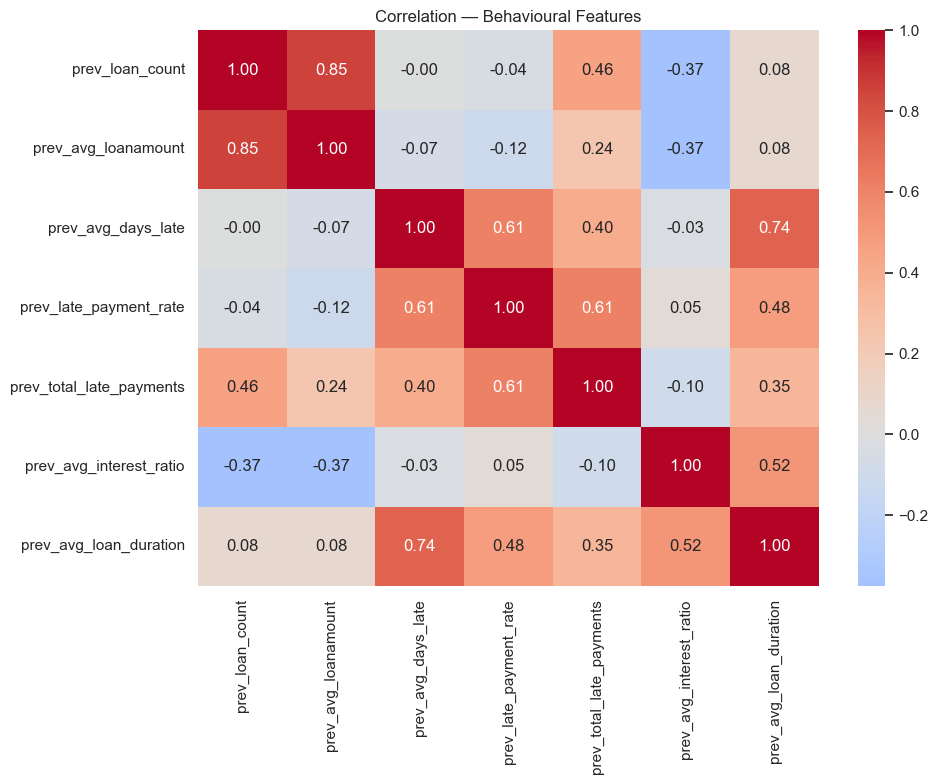

In [75]:
# Correlation heatmap of behavioural features
behavioural_cols = [
    "prev_loan_count", "prev_avg_loanamount", "prev_avg_days_late",
    "prev_late_payment_rate", "prev_total_late_payments",
    "prev_avg_interest_ratio", "prev_avg_loan_duration"
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = merged[behavioural_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — Behavioural Features")
plt.tight_layout()
plt.savefig("../outputs/figures/behavioural_correlation.png", dpi=150)
plt.show()

This correlation heatmap shows that `prev_loan_count` and `prev_avg_loanamount` are strongly correlated at 0.85, they essentially move together. The three lateness features (`prev_avg_days_late`, `prev_late_payment_rate`, `prev_total_late_payments`) are moderately correlated with each other since they all measure the same underlying behaviour from different angles. Nothing here is alarming for tree-based models.

## 7. Summary of Key EDA Findings

- The target is imbalanced but workable. 1 in 5 loans defaults. We cannot use accuracy as a metric. ROC-AUC and F1 on the Bad class are the right measures.

- Loan size tells us almost nothing. The product is essentially standardised at 10,000 naira on 30-day terms. There is no meaningful difference in loan amount between Good and Bad payers, so the current loan's characteristics are weak predictors on their own.

- Demographic data is largely incomplete. Education is 86.5% missing. Employment status is 14.9% missing. These features may contribute something but expectations aren't high for them to carry much weight in the model.

- Customers are young and mostly short-tenured. The typical customer is around 32 years old with 1 to 5 prior loans. A large chunk of the dataset has only one prior loan, which means behavioural features for those customers are built on a single observation.
Prior repayment behaviour is the strongest signal in the data. 

- Bad payers had a prior late payment rate around 65% on average. Good payers were near zero. The separation is clear and consistent. The model's predictive power will come primarily from these behavioural features, not from demographics or current loan characteristics.

- Late payments tend to cluster in the 5 to 15 day range. Most customers pay close to the due date. The tail of very late payers extending past 60 days represents the most serious cases.

We are building a behavioural model. 99.8% of customers have prior loan history. We have the data to score almost everyone based on what they have actually done, not just who they are on paper.